In [3]:
!pip install pytrends praw pandas matplotlib seaborn

In [5]:
#  IMPORT TOOLS

from pytrends.request import TrendReq  # This talks to Google Trends for us
import pandas as pd                    # This organizes data into tables
import time                            # This lets us pause (so Google doesn't block us)
import os                              # This helps us create folders on your computer

print("✅ All tools loaded successfully!")

✅ All tools loaded successfully!


In [7]:
# DEFINE OUR PRODUCTS

products = [
    "PS5",                    # PlayStation 5
    "iPhone 15",              # Apple iPhone
    "Nike Air Jordan",        # Sneaker drops
    "Stanley Cup Tumbler",    # Viral lifestyle product
    "Nvidia RTX 5090"         # GPU - graphics card
]

# Let's print them out so we can see they're saved correctly
print("📦 We are tracking these products:")
for product in products:          # "for" means: do this FOR EACH item in the list
    print(f"   → {product}")      # f"" means: put the variable inside the text

📦 We are tracking these products:
   → PS5
   → iPhone 15
   → Nike Air Jordan
   → Stanley Cup Tumbler
   → Nvidia RTX 5090


In [9]:
# CONNECT TO GOOGLE TRENDS
# This is like opening the Google Trends website but we're doing it through Python instead of a browser

# Create a connection to Google Trends
# hl = "en-US" means: use English language
# tz = 360 means: timezone setting (360 = US Central, doesn't matter much)
pytrends = TrendReq(hl="en-US", tz=360)

print("✅ Connected to Google Trends!")
print("🌐 Ready to collect data...")

✅ Connected to Google Trends!
🌐 Ready to collect data...


In [11]:
# COLLECT GOOGLE TRENDS DATA FOR ALL PRODUCTS
# ============================================================
# Google Trends only lets you compare 5 products at once
# We will collect data for each product one by one and save it all into one big table

# First, create an empty container to store results
# Think of it like an empty Excel spreadsheet waiting to be filled
all_trends_data = {}

# Now loop through each product and collect data
for product in products:
    
    print(f"🔍 Collecting data for: {product} ...")
    
    # Tell Google Trends WHAT we want to search
    # timeframe = how far back we want data
    # "today 5-y" means: last 5 years
    # geo = "" means: worldwide (not just one country)
    pytrends.build_payload(
        kw_list=[product],       # kw_list = keyword list = what to search
        timeframe="today 5-y",   # last 5 years of data
        geo=""                   # worldwide data
    )
    
    # Now actually GO and get the data from Google
    # interest_over_time() = "how much interest over time?"
    data = pytrends.interest_over_time()
    
    # Sometimes Google returns empty data — let's handle that
    if data.empty:
        print(f"   ⚠️ No data found for {product}, skipping...")
    else:
        # Save this product's search numbers into our container
        # data[product] = just the numbers column for this product
        all_trends_data[product] = data[product]
        print(f"   ✅ Got {len(data)} weeks of data for {product}")
    
    # IMPORTANT: Wait 2 seconds between each request
    # Why? Because Google will block us if we ask too fast
    # It's like waiting in line — don't push!
    time.sleep(2)

print("\n🎉 Data collection complete!")
print(f"📊 Total products collected: {len(all_trends_data)}")

🔍 Collecting data for: PS5 ...


/opt/anaconda3/lib/python3.12/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


   ✅ Got 262 weeks of data for PS5
🔍 Collecting data for: iPhone 15 ...


/opt/anaconda3/lib/python3.12/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


   ✅ Got 262 weeks of data for iPhone 15
🔍 Collecting data for: Nike Air Jordan ...


...

   ✅ Got 262 weeks of data for Nike Air Jordan
🔍 Collecting data for: Stanley Cup Tumbler ...


/opt/anaconda3/lib/python3.12/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


   ✅ Got 262 weeks of data for Stanley Cup Tumbler
🔍 Collecting data for: Nvidia RTX 5090 ...


/opt/anaconda3/lib/python3.12/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


   ✅ Got 262 weeks of data for Nvidia RTX 5090

🎉 Data collection complete!
📊 Total products collected: 5


In [15]:
# ORGANIZE DATA INTO A CLEAN TABLE
# ============================================================
# Right now our data is scattered in a dictionary (like a messy bag)
# pandas DataFrame = a proper organized TABLE (like Excel)
# We're going to put everything into one clean table

# pd.DataFrame() turns our collected data into a table
trends_df = pd.DataFrame(all_trends_data)

# Fill any missing values with 0
# (some weeks might have no data — we replace blank with 0)
trends_df = trends_df.fillna(0)

# Let's see what our table looks like
print("📋 HERE IS YOUR DATA TABLE:")
print(f"   Rows (weeks of data): {len(trends_df)}")
print(f"   Columns (products):   {len(trends_df.columns)}")
print()
print(trends_df.head(10))   # .head(10) = show first 10 rows only

📋 HERE IS YOUR DATA TABLE:
   Rows (weeks of data): 262
   Columns (products):   5

            PS5  iPhone 15  Nike Air Jordan  Stanley Cup Tumbler  \
date                                                               
2021-04-11   34          0               66                    0   
2021-04-18   30          0               64                    0   
2021-04-25   32          0               63                    0   
2021-05-02   31          0               64                    0   
2021-05-09   31          0               62                    0   
2021-05-16   31          0               59                    0   
2021-05-23   30          0               56                    0   
2021-05-30   29          0               56                    0   
2021-06-06   31          0               52                    1   
2021-06-13   33          0               51                    0   

            Nvidia RTX 5090  
date                         
2021-04-11                0  
2021-04-1

In [17]:
# ============================================================
# CELL 6: SAVE THE DATA AS A CSV FILE
# ============================================================
# CSV = like an Excel file but simpler
# We save it so we NEVER have to collect it again
# (next time we just load the saved file — much faster!)

# First make sure the "data" folder exists
# os.makedirs = "make the directory (folder) if it doesn't exist"
os.makedirs("../data", exist_ok=True)   
# "../data" means: go one folder up, then into "data"
# exist_ok=True means: don't crash if the folder already exists

# Save our table as a CSV file
save_path = "../data/google_trends.csv"
trends_df.to_csv(save_path)

print(f"💾 Data saved successfully!")
print(f"📁 Location: {save_path}")
print(f"📊 Shape of data: {trends_df.shape[0]} rows × {trends_df.shape[1]} columns")

💾 Data saved successfully!
📁 Location: ../data/google_trends.csv
📊 Shape of data: 262 rows × 5 columns


/var/folders/hm/yxwbcxy96ys1rb0_3_1sl01w0000gn/T/ipykernel_50365/322839376.py:41: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/hm/yxwbcxy96ys1rb0_3_1sl01w0000gn/T/ipykernel_50365/322839376.py:44: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.savefig("../data/trends_chart.png", dpi=150, bbox_inches="tight")


📊 Chart saved as trends_chart.png


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


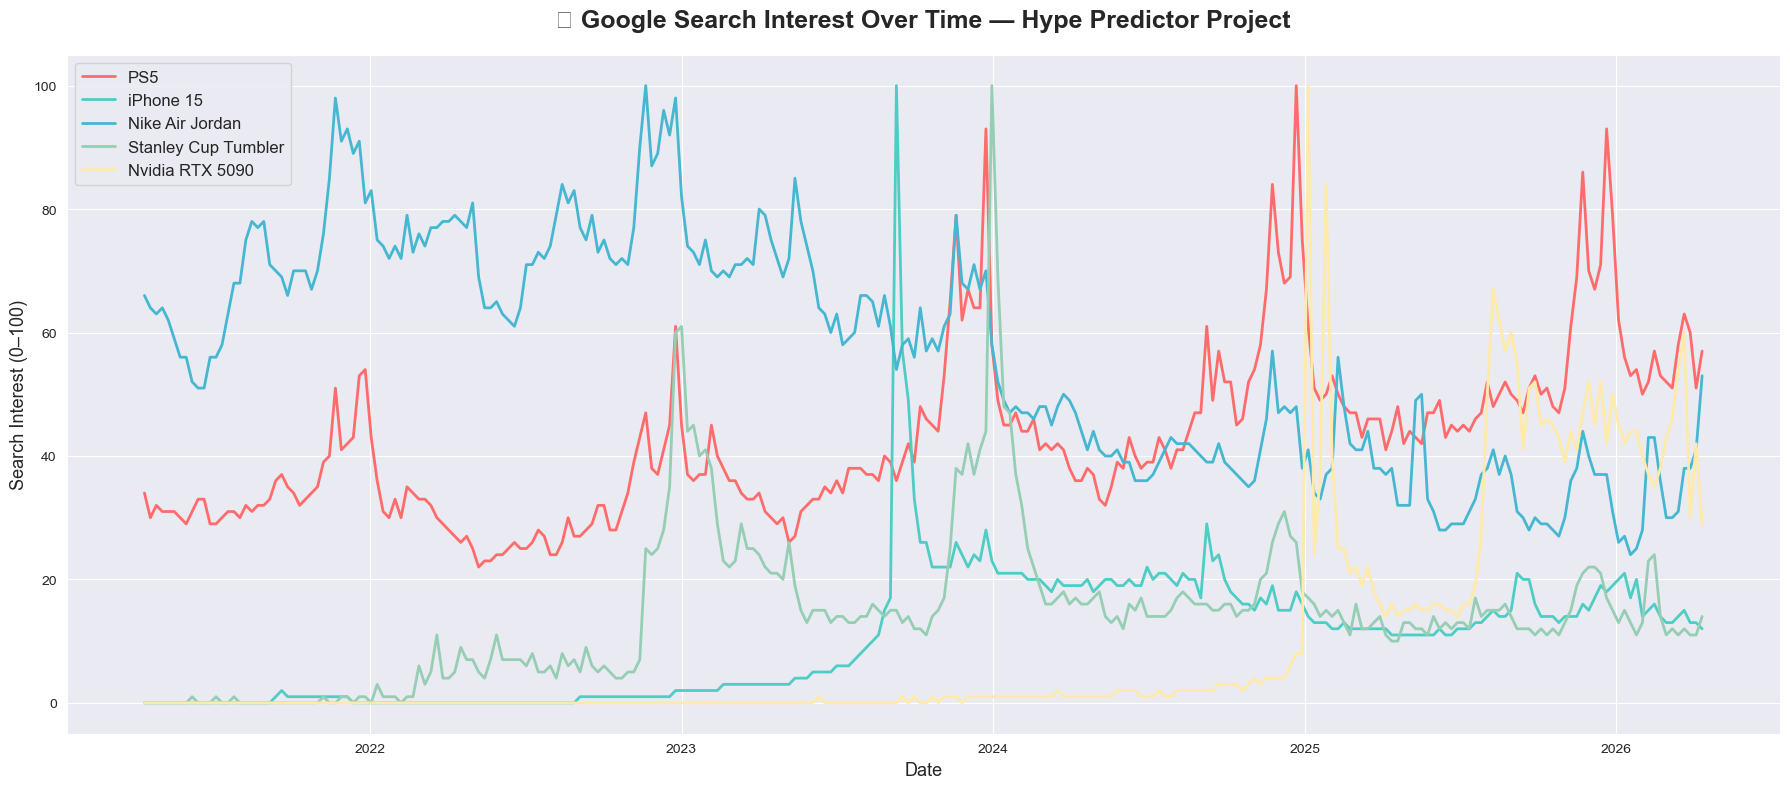


✅ LESSON 1 COMPLETE!
You just collected real data from Google and made a professional chart.
Files saved:
   → ../data/google_trends.csv
   → ../data/trends_chart.png


In [19]:
# ============================================================
# CELL 7: VISUALIZE THE DATA — YOUR FIRST CHART!
# ============================================================
import matplotlib.pyplot as plt    # This draws charts
import matplotlib.dates as mdates  # This formats dates on charts
import seaborn as sns              # This makes charts look professional

# Set the visual style — "darkgrid" looks clean and professional
sns.set_style("darkgrid")

# Set the figure size — (18, 8) means wide and tall enough to read
plt.figure(figsize=(18, 8))

# Define nice colors for each product line
colors = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7"]

# Draw one line per product
for i, product in enumerate(trends_df.columns):
    plt.plot(
        trends_df.index,          # X axis = dates
        trends_df[product],       # Y axis = search interest numbers
        label=product,            # label = name shown in legend
        color=colors[i],          # color from our list above
        linewidth=2               # linewidth = how thick the line is
    )

# Add titles and labels — always label your charts!
plt.title(
    "🔥 Google Search Interest Over Time — Hype Predictor Project",
    fontsize=18,
    fontweight="bold",
    pad=20
)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Search Interest (0–100)", fontsize=13)

# Add a legend so we know which line is which product
plt.legend(fontsize=12, loc="upper left")

# Make it look tight and clean
plt.tight_layout()

# Save the chart as an image file
plt.savefig("../data/trends_chart.png", dpi=150, bbox_inches="tight")
print("📊 Chart saved as trends_chart.png")

# Show the chart right here in Jupyter
plt.show()

print("\n✅ LESSON 1 COMPLETE!")
print("You just collected real data from Google and made a professional chart.")
print("Files saved:")
print("   → ../data/google_trends.csv")
print("   → ../data/trends_chart.png")

In [21]:
import os

# Search your entire Desktop for our files
print("🔍 Searching for your files...")
print()

desktop = "/Users/sanjana/Desktop"

for root, dirs, files in os.walk(desktop):
    for file in files:
        if file.endswith(".csv") or file.endswith(".png"):
            full_path = os.path.join(root, file)
            print(f"✅ Found: {full_path}")

🔍 Searching for your files...

✅ Found: /Users/sanjana/Desktop/Screenshot 2026-02-16 at 11.40.21 PM.png
✅ Found: /Users/sanjana/Desktop/Screenshot 2026-02-02 at 9.40.05 PM.png
✅ Found: /Users/sanjana/Desktop/Screenshot 2026-02-02 at 9.54.25 PM.png
✅ Found: /Users/sanjana/Desktop/Screenshot 2026-04-12 at 12.43.26 AM.png
✅ Found: /Users/sanjana/Desktop/Screenshot 2026-02-02 at 9.53.36 PM.png
✅ Found: /Users/sanjana/Desktop/Screenshot 2026-02-16 at 11.39.05 PM.png
✅ Found: /Users/sanjana/Desktop/Screenshot 2026-02-10 at 7.27.13 PM.png
✅ Found: /Users/sanjana/Desktop/Screenshot 2026-02-02 at 9.57.05 PM.png
✅ Found: /Users/sanjana/Desktop/Screenshot 2026-04-12 at 12.52.03 AM.png
✅ Found: /Users/sanjana/Desktop/Screenshot 2026-02-18 at 1.36.01 PM.png
✅ Found: /Users/sanjana/Desktop/Screenshot 2026-02-02 at 9.38.44 PM.png
✅ Found: /Users/sanjana/Desktop/People Analytics/Southwest Airlines Employee Experience Survey.csv
✅ Found: /Users/sanjana/Desktop/People Analytics/sales.csv


In [23]:
import os
import shutil

# Step 1 - Find where the files actually got saved
print("🔍 Looking for your files...\n")

# Check the most likely location
possible_locations = [
    os.path.expanduser("~/data"),
    os.path.expanduser("~/Desktop/data"),
    os.path.expanduser("~/Desktop/Hype-Predictor/data"),
    os.path.expanduser("~/Desktop/Hype-Predictor/Data"),
    os.getcwd() + "/../data",
    os.getcwd() + "/data",
]

found_csv = None
found_png = None

for location in possible_locations:
    location = os.path.abspath(location)
    if os.path.exists(location):
        files = os.listdir(location)
        for f in files:
            if "google_trends" in f:
                found_csv = os.path.join(location, f)
                print(f"✅ Found CSV at: {found_csv}")
            if "trends_chart" in f:
                found_png = os.path.join(location, f)
                print(f"✅ Found Chart at: {found_png}")

if not found_csv and not found_png:
    print("❌ Files not found in usual places")
    print(f"📍 Your notebook is currently running from:")
    print(f"   {os.getcwd()}")

🔍 Looking for your files...

✅ Found Chart at: /Users/sanjana/data/trends_chart.png
✅ Found CSV at: /Users/sanjana/data/google_trends.csv
✅ Found Chart at: /Users/sanjana/data/trends_chart.png
✅ Found CSV at: /Users/sanjana/data/google_trends.csv


In [25]:
import os

# ============================================================
# MASTER PATH SETUP — RUN THIS AT THE START OF EVERY NOTEBOOK
# ============================================================
# This is YOUR exact folder location on YOUR Mac
# Capital letters must match exactly

DATA_PATH      = "/Users/sanjana/Desktop/Hype-Predictor/Data"
NOTEBOOKS_PATH = "/Users/sanjana/Desktop/Hype-Predictor/Notebooks"

# Confirm everything exists
print("📁 YOUR PROJECT PATHS:")
print(f"   Data folder:      {DATA_PATH}")
print(f"   Notebooks folder: {NOTEBOOKS_PATH}")
print()

# List your files
print("📄 FILES IN YOUR DATA FOLDER:")
for file in os.listdir(DATA_PATH):
    size = os.path.getsize(f"{DATA_PATH}/{file}")
    print(f"   ✅ {file}  —  {size:,} bytes")

print()
print("🎉 Everything is confirmed and ready!")
print("🚀 You are ready for Lesson 2!")

📁 YOUR PROJECT PATHS:
   Data folder:      /Users/sanjana/Desktop/Hype-Predictor/Data
   Notebooks folder: /Users/sanjana/Desktop/Hype-Predictor/Notebooks

📄 FILES IN YOUR DATA FOLDER:
   ✅ trends_chart.png  —  375,560 bytes
   ✅ google_trends.csv  —  6,489 bytes

🎉 Everything is confirmed and ready!
🚀 You are ready for Lesson 2!


In [27]:
# ============================================================
# RUN THIS FIRST IN EVERY FUTURE NOTEBOOK
# It tells Python exactly where YOUR project lives
# ============================================================

import os

# YOUR permanent project paths — these never change
DATA_PATH      = "/Users/sanjana/Desktop/Hype-Predictor/Data"
NOTEBOOKS_PATH = "/Users/sanjana/Desktop/Hype-Predictor/Notebooks"

# Make sure both folders exist
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(NOTEBOOKS_PATH, exist_ok=True)

print("✅ Paths locked in!")
print(f"   Data:      {DATA_PATH}")
print(f"   Notebooks: {NOTEBOOKS_PATH}")

✅ Paths locked in!
   Data:      /Users/sanjana/Desktop/Hype-Predictor/Data
   Notebooks: /Users/sanjana/Desktop/Hype-Predictor/Notebooks


In [29]:
# This saves your notebook to the correct Notebooks folder
# We are just confirming the right place
import shutil
import os

print("📁 Your notebook should be saved here:")
print("   /Users/sanjana/Desktop/Hype-Predictor/Notebooks/")
print()
print("👉 In Jupyter — click File → Save As")
print("   Navigate to: Desktop → Hype-Predictor → Notebooks")
print("   Name it: 01_Google_Trends_Data")

📁 Your notebook should be saved here:
   /Users/sanjana/Desktop/Hype-Predictor/Notebooks/

👉 In Jupyter — click File → Save As
   Navigate to: Desktop → Hype-Predictor → Notebooks
   Name it: 01_Google_Trends_Data
